In [1]:
import numpy as np
import lal
import lalsimulation as ls
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from bilby.gw.conversion import chirp_mass_and_mass_ratio_to_component_masses
import bilby
from pycbc.detector import Detector
from pycbc.conversions import det_tc
import dill
import time

/tmp/ipykernel_156977/2143038490.py:2: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


# 100 seconds long signal

In [2]:
Detectors_list = {"L1":Detector("L1"),"H1":Detector("H1")}
injection_parameters = {
 'ra': 0.27978624978955047,
 'dec': 0.8177904807920127,
 'psi': 2.556511615810729,
 'phase': 1.0438142141860045,
 'geocent_time': 1126259462.4667501}

Time_array = np.arange(-100+0.5,0.5,1/4096.0, dtype = np.float64) + injection_parameters["geocent_time"]

F_plus, F_cross = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=Time_array,
            )

F_plus_at_merger, F_cross_at_merger = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=injection_parameters["geocent_time"],
            )

In [3]:
idx = np.where(Time_array == injection_parameters["geocent_time"])[0]

In [4]:
F_plus[idx][0], F_cross[idx][0]

(-0.9736238998532911, 0.21913178440228043)

In [5]:
F_plus_at_merger, F_cross_at_merger

(-0.9736238998532911, 0.21913178440228043)

In [6]:
for i in range(100000):
    F_plus_at_merger, F_cross_at_merger = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=injection_parameters["geocent_time"],
            )

In [7]:
for i in range(100):
    F_plus, F_cross = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=Time_array,
            )

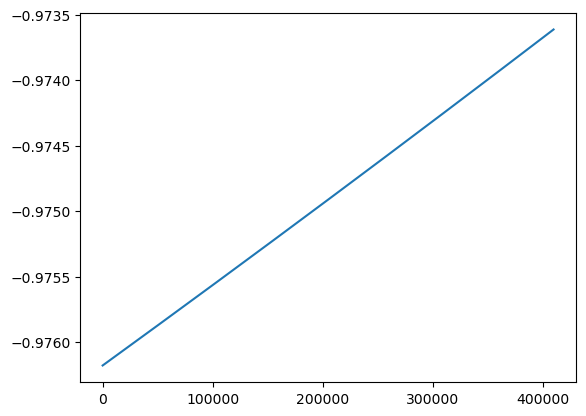

In [8]:
plt.plot(F_plus, label = r"$F_+$")
# plt.plot(F_cross, label = r"$F_\times$")

# 1024 second long signal

In [9]:
Time_array = np.arange(-1024+0.5,0.5,1/4096.0, dtype = np.float64) + injection_parameters["geocent_time"]

In [10]:
for i in range(10):
    F_plus, F_cross = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=Time_array,
            )

In [26]:
(8.09 / 10 *int(1e7)) / 3600  # These many hours 

2247.222222222222

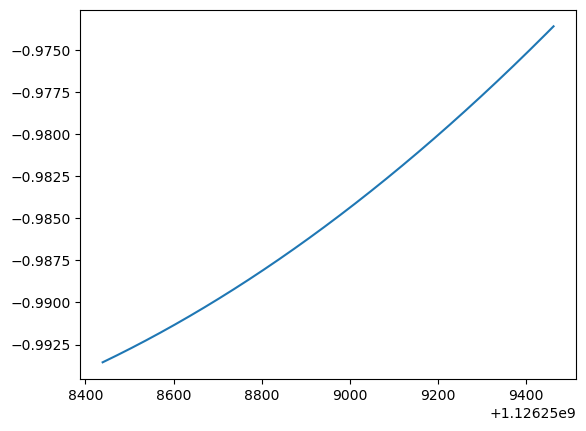

In [12]:
plt.plot(Time_array,F_plus, label = r"$F_+$")

# 2048 second long signal

In [13]:
Time_array = np.arange(-2048+0.5,0.5,1/4096.0, dtype = np.float64) + injection_parameters["geocent_time"]

for i in range(10):
    F_plus, F_cross = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=Time_array,
            )

In [14]:
(19.83 / 10 *int(1e7)) / 3600  # These many hours for 1e7 likelihood evaluations.

5508.333333333333

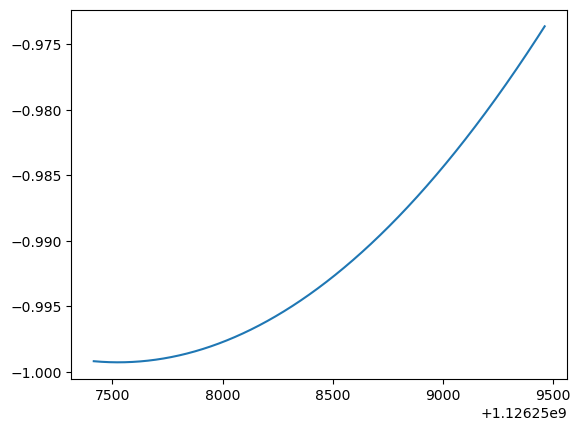

In [15]:
plt.plot(Time_array,F_plus, label = r"$F_+$")

In [28]:
Time_array = np.arange(-2+0.5,0.5,1/4096.0, dtype = np.float64) + injection_parameters["geocent_time"]

for i in range(100000):
    F_plus, F_cross = Detectors_list["H1"].antenna_pattern(
                right_ascension=injection_parameters["ra"],
                declination=injection_parameters["dec"],
                polarization=injection_parameters["psi"],
                t_gps=Time_array[::40],
            )

In [34]:
9.93/100000 *1000

0.0993

In [29]:
(10/100000 * int(2e7)) / 3600   # These many hours for 1e7 likelihood evaluations but with relative binning 

0.5555555555555556

In [30]:
len(F_plus) # Number of bins

205